# Validação 30 — busca científica expandida e reranking

Este notebook valida, com dados controlados, a ampliação da busca por alegação e a remoção auditável de candidatos que compartilham palavras, mas não cobrem os conceitos centrais.

## tl;dr

A busca passa a registrar estratégias temática, MeSH candidata, síntese de evidências, DOI e autor. No cenário controlado, o reranker mantém os trabalhos que cobrem a alegação e rejeita os dois ruídos lexicais, incluindo um vizinho do grafo sem relação temática suficiente. Citação ou proximidade no grafo não é tratada como prova de qualidade.

## Contexto e método

A unidade de busca é uma alegação atômica. O plano combina consultas textuais com DOI/autor e pode receber vizinhos do PubMed e referências, citações e relacionados do OpenAlex. O teste abaixo não chama serviços externos: ele mede deterministicamente a expansão e o reranking.

### Premissas principais

- O vocabulário local de sinônimos e descritores é inicial e não substitui um indexador MeSH.
- O reranking desta etapa usa título, proveniência e cobertura conceitual; a compatibilidade final continua dependendo dos trechos do texto completo ou abstract.
- Contagem de citações e ligação no grafo ampliam cobertura, mas não demonstram qualidade metodológica.

## Configuração

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
from IPython.display import display
from fatofake.federated_search import ScientificWork, SourceRank
from fatofake.scientific_search import ClaimRelevanceReranker, expand_scientific_queries

CLAIM = 'Hydrostatic pressure changes rhodopsin hydration.'
BASE_QUERY = 'hydrostatic pressure rhodopsin hydration'

## 1. Expandir a consulta com proveniência

In [2]:
expanded = expand_scientific_queries(
    CLAIM,
    (BASE_QUERY,),
    seed_doi='10.1000/rhodopsin',
    seed_authors=('Ana Silva',),
)
[(item.strategy, item.query) for item in expanded]

[('THEMATIC', 'hydrostatic pressure rhodopsin hydration'),
 ('MESH_CANDIDATES', '"Rhodopsin" AND "Hydrostatic Pressure"'),
 ('EVIDENCE_SYNTHESIS',
  '(hydrostatic pressure rhodopsin hydration) (systematic review OR meta-analysis)'),
 ('SEED_DOI', '10.1000/rhodopsin'),
 ('SEED_AUTHOR', '"Ana Silva" hydrostatic pressure rhodopsin hydration')]

As estratégias ficam explícitas para auditoria. Termos MeSH são candidatos conhecidos, e não uma classificação inventada para qualquer expressão.

## 2. Criar candidatos controlados

In [3]:
def make_work(title, identifier, source='PubMed', rank=1):
    return ScientificWork(
        title=title, authors=(), journal=None, publication_date='2024',
        doi=f'10.1000/{identifier}', pmid=identifier,
        url=f'https://example.org/{identifier}', matched_queries=(BASE_QUERY,),
        sources=(source,), source_ids=((source, identifier),),
        source_ranks=(SourceRank(source, BASE_QUERY, rank),),
        retrieval_score=1 / (60 + rank),
    )

candidates = (
    make_work('Hydrostatic pressure controls hydration and activation of rhodopsin', '1'),
    make_work('Hydration-dependent conformational equilibrium of rhodopsin', '2', 'OpenAlex referências', 2),
    make_work('Hydrostatic pressure during coffee extraction', '3', rank=3),
    make_work('Coffee extraction temperature', '4', 'OpenAlex relacionados', 4),
)
ranked = ClaimRelevanceReranker().rank(CLAIM, candidates)
rows = [
    {
        'título': item.work.title, 'pontuação': item.score,
        'aceito': item.accepted, 'conceitos': ', '.join(item.concept_matches),
    }
    for item in ranked
]
rows

[{'título': 'Hydrostatic pressure controls hydration and activation of rhodopsin',
  'pontuação': 0.85,
  'aceito': True,
  'conceitos': 'hydration, hydrostatic_pressure, rhodopsin'},
 {'título': 'Hydration-dependent conformational equilibrium of rhodopsin',
  'pontuação': 0.6809,
  'aceito': True,
  'conceitos': 'hydration, rhodopsin'},
 {'título': 'Hydrostatic pressure during coffee extraction',
  'pontuação': 0.4119,
  'aceito': False,
  'conceitos': 'hydrostatic_pressure'},
 {'título': 'Coffee extraction temperature',
  'pontuação': 0.243,
  'aceito': False,
  'conceitos': ''}]

## 3. Visualizar a decisão do reranker

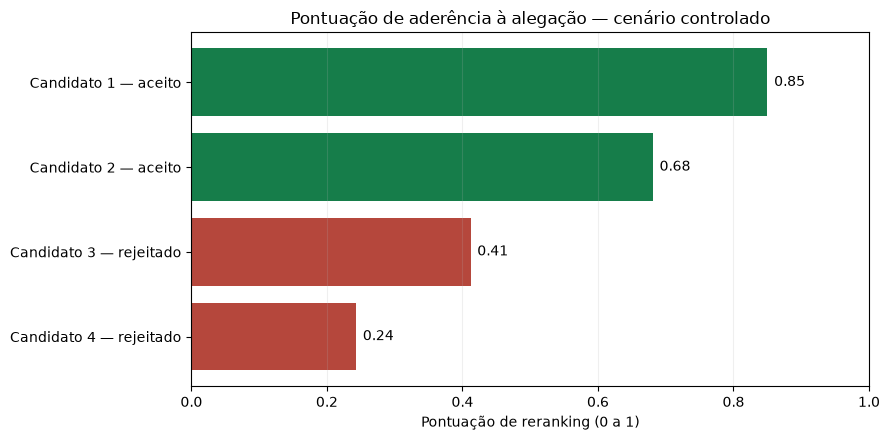

In [4]:
labels = [f"Candidato {index} — {'aceito' if item.accepted else 'rejeitado'}" for index, item in enumerate(ranked, 1)]
scores = [item.score for item in ranked]
colors = ['#167d4a' if item.accepted else '#b5473c' for item in ranked]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1])
ax.set_title('Pontuação de aderência à alegação — cenário controlado')
ax.set_xlabel('Pontuação de reranking (0 a 1)')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=.2)
for bar, score in zip(bars, scores[::-1]):
    ax.text(score + .01, bar.get_y() + bar.get_height()/2, f'{score:.2f}', va='center')
plt.tight_layout()
display(fig, metadata={'image/png': {'alt': 'Barras de pontuação: dois candidatos aceitos em verde e dois rejeitados em vermelho.'}})
plt.close(fig)

Verde indica que o título cobre conceitos suficientes da alegação; vermelho indica exclusão. O vizinho do OpenAlex sem conceito em comum permanece rejeitado, mostrando que proximidade no grafo não vence a aderência temática.

## 4. Verificações executáveis

In [5]:
strategies = {item.strategy for item in expanded}
assert {'THEMATIC', 'MESH_CANDIDATES', 'EVIDENCE_SYNTHESIS', 'SEED_DOI', 'SEED_AUTHOR'} <= strategies
assert sum(item.accepted for item in ranked) == 2
assert sum(not item.accepted for item in ranked) == 2
assert ranked[0].work.pmid == '1'
assert not next(item for item in ranked if item.work.pmid == '4').accepted
print('OK: expansão rastreável e reranking conservador validados.')

OK: expansão rastreável e reranking conservador validados.


## Resultados e próximos passos

O cenário produziu cinco estratégias auditáveis, aceitou 2 de 4 candidatos e rejeitou 2 ruídos. A busca em produção também incorpora vizinhos do PubMed e o grafo do OpenAlex, isolando falhas de cada canal. A próxima etapa deve criar um conjunto de avaliação conhecido para medir Recall@K, Precision@K, qualidade dos trechos, abstenção e estabilidade; só então os limites do reranker poderão ser calibrados.